## Celda 1: Análisis de Reproducibilidad — Músculo Corrugador

Esta celda visualiza la tendencia individual de la tensión del músculo corrugador (`emg_corrugator_mean`) para una muestra de 5 sujetos a lo largo de los 5 niveles de dolor del dataset BioVid (BL1 a PA4).

Se aíslan 5 sujetos específicos con el objetivo de reducir la complejidad visual del gráfico y poder identificar con claridad los patrones individuales. Graficar todos los sujetos produciría un resultado ilegible.

La variable `class_name` se convierte a tipo Categorical con un orden explícito para garantizar que el eje X respete la secuencia cronológica del estímulo doloroso (BL1 → PA1 → PA2 → PA3 → PA4) y no un orden alfabético que distorsionaría la interpretación.

**Salida:** Gráfico de líneas en pantalla y archivo `tendencia_reproducibilidad.png` exportado en alta definición (300 dpi).

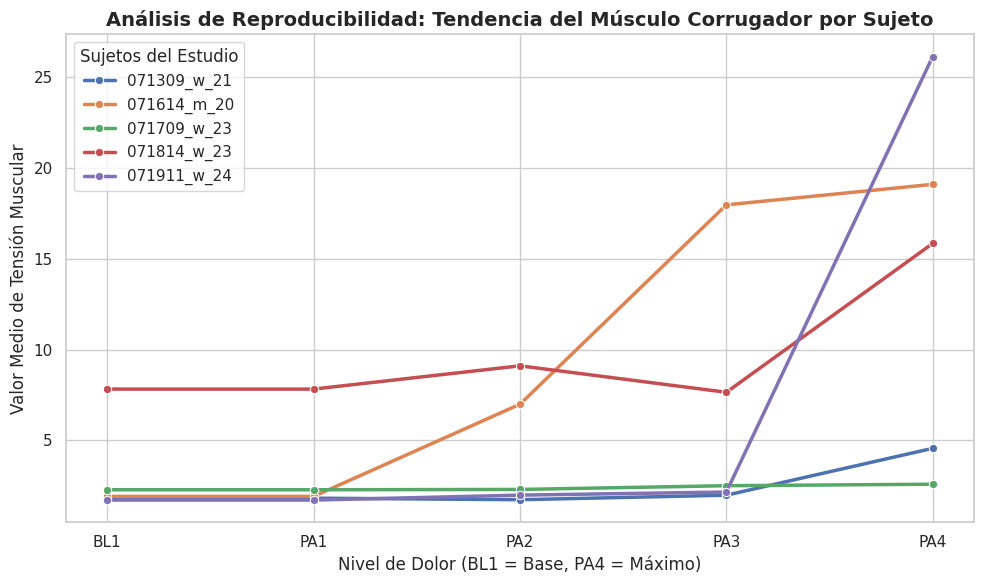

In [ ]:
# Primera version del codigo.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset de BioVid
# RECUERDA: Ajusta esta ruta a donde tengas el archivo en tu Google Drive
df_biovid = pd.read_csv('/content/drive/Shareddrives/GPI/dataset_features_biovid.csv')

# 2. Seleccionar los primeros 5 sujetos únicos para analizar sus trayectorias individuales
sujetos_muestra = df_biovid['subject_name'].unique()[:5]
df_muestra = df_biovid[df_biovid['subject_name'].isin(sujetos_muestra)].copy()

# 3. Definir y aplicar el orden cronológico del estímulo doloroso
orden_clases = ['BL1', 'PA1', 'PA2', 'PA3', 'PA4']
df_muestra['class_name'] = pd.Categorical(df_muestra['class_name'], categories=orden_clases, ordered=True)

# 4. Graficar la tendencia individual del músculo del ceño (Corrugator)
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='class_name',
    y='emg_corrugator_mean',
    hue='subject_name',
    data=df_muestra,
    marker='o',
    linewidth=2.5,
    errorbar=None
)

plt.title('Análisis de Reproducibilidad: Tendencia del Músculo Corrugador por Sujeto', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Dolor (BL1 = Base, PA4 = Máximo)', fontsize=12)
plt.ylabel('Valor Medio de Tensión Muscular', fontsize=12)
plt.legend(title='Sujetos del Estudio')
plt.tight_layout()

# Guardar la imagen en alta definición
plt.savefig('tendencia_reproducibilidad.png', dpi=300)
plt.show()